# Phase 3: Machine Learning for Brace Detection

## Project: OrthoAnalytics - Clinical Gait Study

In this phase, we build a predictive model to automatically identify the orthopedic intervention (None, Knee-Braced, Ankle-Braced) based on gait kinematics. This has applications in remote patient monitoring and rehabilitation compliance.

### Objectives:
1. **Feature Engineering**: Transform time-series gait cycles into summary features (ROM, Mean, SD).
2. **Classification**: Train a Random Forest classifier to detect the brace type.
3. **Evaluation**: Analyze model performance using a confusion matrix and classification report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visual style
sns.set_theme(style="whitegrid")

# Load data
data_path = "../data/raw/gait.csv"
df = pd.read_csv(data_path)

# Metadata mapping
joint_map = {1: 'Ankle', 2: 'Knee', 3: 'Hip'}
leg_map = {1: 'Left', 2: 'Right'}
condition_map = {1: 'Unbraced', 2: 'Knee-Braced', 3: 'Ankle-Braced'}

df['joint_name'] = df['joint'].map(joint_map)
df['leg_name'] = df['leg'].map(leg_map)

### 1. Feature Engineering
We extract statistical summaries from the raw gait cycles to create a structured dataset for machine learning.

In [2]:
def extract_features(group):
    return pd.Series({
        'ROM': group.max() - group.min(),
        'Mean': group.mean(),
        'Std': group.std(),
        'Max': group.max(),
        'Min': group.min()
    })

# Group and calculate summary stats
features_raw = df.groupby(['subject', 'condition', 'replication', 'leg_name', 'joint_name'])['angle'].apply(extract_features)

# Unstack to get a flat feature vector per gait cycle
# Level -3: leg_name, Level -2: joint_name, Level -1: the statistic (ROM, Mean, etc.)
features = features_raw.unstack(level=[-3, -2, -1])

# Flatten MultiIndex columns into names like 'Right_Knee_ROM'
features.columns = [f"{col[0]}_{col[1]}_{col[2]}" for col in features.columns]
features = features.reset_index()

print(f"Feature matrix shape: {features.shape}")
features.head()

Feature matrix shape: (300, 33)


,subject,condition,replication,Left_Ankle_ROM,Left_Ankle_Mean,Left_Ankle_Std,Left_Ankle_Max,Left_Ankle_Min,Left_Hip_ROM,Left_Hip_Mean,...,Right_Hip_ROM,Right_Hip_Mean,Right_Hip_Std,Right_Hip_Max,Right_Hip_Min,Right_Knee_ROM,Right_Knee_Mean,Right_Knee_Std,Right_Knee_Max,Right_Knee_Min
0,1,1,1,20.722793,7.850984,5.137240,13.369976,-7.352817,37.366456,4.597241,...,35.621442,5.737394,12.731324,22.082553,-13.538889,60.354241,22.231482,18.466275,62.445295,2.091054
1,1,1,2,23.242669,7.003371,5.667427,13.221472,-10.021197,37.976146,2.934972,...,37.310610,7.028008,12.736948,24.109056,-13.201554,63.913118,24.393793,19.666292,66.191037,2.277918
2,1,1,3,20.536000,6.907690,5.103548,12.662596,-7.873404,37.492859,4.043684,...,39.638053,5.152094,13.457144,23.434250,-16.203803,61.967375,23.229125,18.874316,65.300057,3.332682
3,1,1,4,19.325703,6.380351,4.719326,11.780479,-7.545224,38.541116,4.930818,...,39.586723,6.430136,13.252426,24.997317,-14.589406,62.695329,23.377511,18.796025,65.802016,3.106687
4,1,1,5,19.223413,6.618724,4.705380,13.014492,-6.208922,37.270579,4.116368,...,37.978543,5.738954,12.965368,22.574356,-15.404187,63.011498,21.839641,18.954727,64.093660,1.082161


### 2. Model Training
We use a Random Forest Classifier to identify the brace condition.

In [3]:
X = features.drop(['subject', 'condition', 'replication'], axis=1)
y = features['condition']

# Stratified split to ensure all classes are represented in train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Overall Accuracy: 100.00%


### 3. Evaluation and Feature Importance

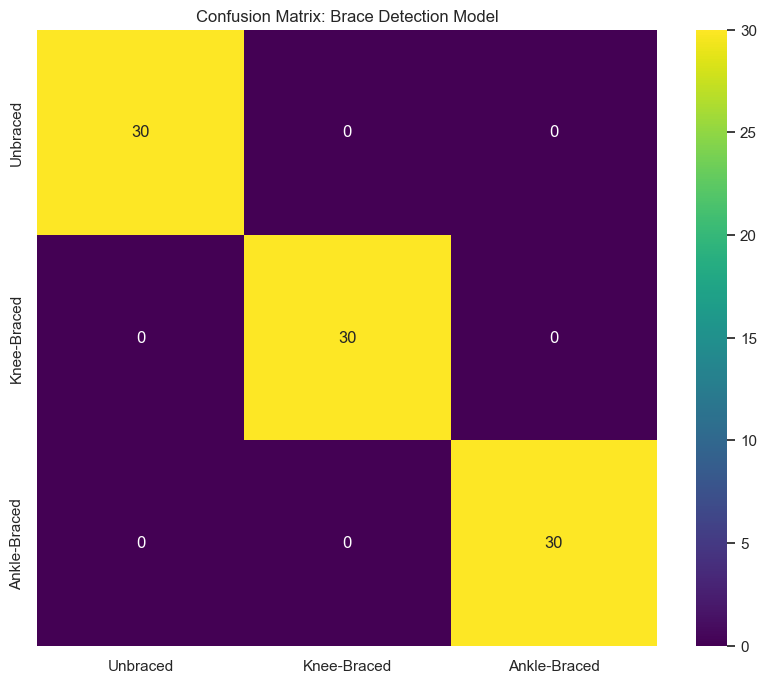

Classification Report:
              precision    recall  f1-score   support

    Unbraced       1.00      1.00      1.00        30
 Knee-Braced       1.00      1.00      1.00        30
Ankle-Braced       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



/var/folders/y6/plfvbl_x6f5g3pv5rs9pcn100000gn/T/ipykernel_30115/313292701.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='importance', y='feature', palette='magma')


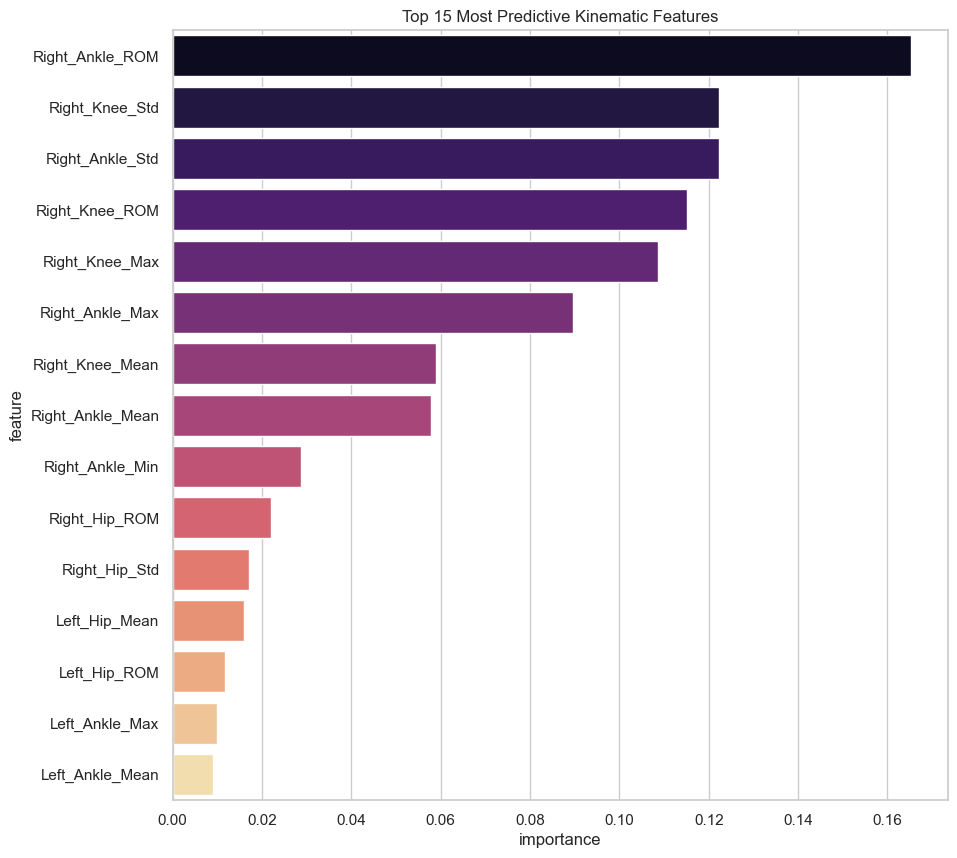

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=condition_map.values(), yticklabels=condition_map.values(), cmap='viridis')
plt.title('Confusion Matrix: Brace Detection Model')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=condition_map.values()))

# Variable Importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(data=importances.head(15), x='importance', y='feature', palette='magma')
plt.title('Top 15 Most Predictive Kinematic Features')
plt.show()